In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from helper.quantumScarFunctions import *
from helper.quantumScarsPlotting import *

In [ ]:
N_list = [4, 6, 8, 10, 12]
wd = 0.6366896896896898
wm = 1.0
t_max = 100
tlist = np.linspace(0, t_max, 200)
reals = 500
dis = 0.3

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

Done with N=4
Done with N=6
Done with N=8
Done with N=10
Done with N=12
Done with N=14


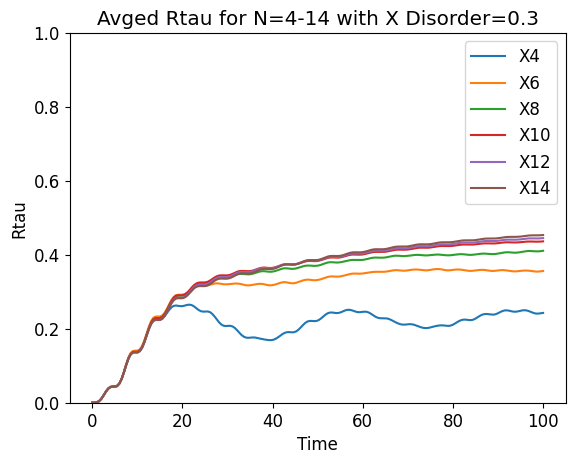

In [19]:
for N in N_list:
    H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
    H1, driveWeights = get_scar_H1(N, basisList)

    xfull_scar = 0
    for _ in range(reals):
        H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[0, 0, dis])
        bandwidth = eigenvalues[-1] - eigenvalues[0]

        H = qt.QobjEvo([H0, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
        xfull_scar += Rtau_scar

    xfull_scar = xfull_scar / reals

    plt.plot(tlist, xfull_scar, label=f"X{N}")
    print(f"Done with N={N}")

plt.title(f"Avged Rtau for N={min(N_list)}-{max(N_list)} with X Disorder={dis}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.legend()
plt.ylim(0, 1)
plt.show()

Done with N=4
Done with N=6
Done with N=8
Done with N=10
Done with N=12
Done with N=14


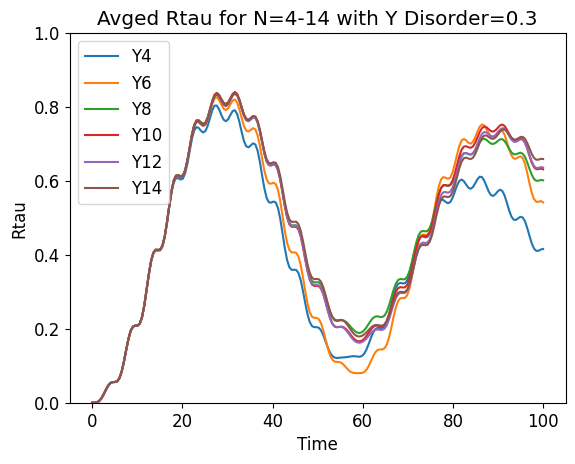

In [20]:
for N in N_list:
    H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
    H1, driveWeights = get_scar_H1(N, basisList)

    yfull_scar = 0
    for _ in range(reals):
        H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[0, dis, 0])
        bandwidth = eigenvalues[-1] - eigenvalues[0]

        H = qt.QobjEvo([H0, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
        yfull_scar += Rtau_scar

    yfull_scar = yfull_scar / reals

    plt.plot(tlist, yfull_scar, label=f"Y{N}")
    print(f"Done with N={N}")

plt.title(f"Avged Rtau for N={min(N_list)}-{max(N_list)} with Y Disorder={dis}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.legend()
plt.ylim(0, 1)
plt.show()

Done with N=4
Done with N=6
Done with N=8
Done with N=10
Done with N=12
Done with N=14


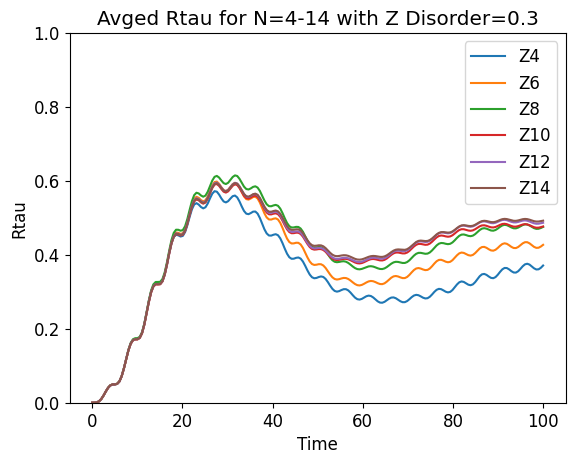

In [21]:
for N in N_list:
    H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
    H1, driveWeights = get_scar_H1(N, basisList)

    zfull_scar = 0
    for _ in range(reals):
        H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dis, 0, 0])
        bandwidth = eigenvalues[-1] - eigenvalues[0]

        H = qt.QobjEvo([H0, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
        zfull_scar += Rtau_scar

    zfull_scar = zfull_scar / reals

    plt.plot(tlist, zfull_scar, label=f"Z{N}")
    print(f"Done with N={N}")

plt.title(f"Avged Rtau for N={min(N_list)}-{max(N_list)} with Z Disorder={dis}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.legend()
plt.ylim(0, 1)
plt.show()